# 03 · Unsupervised technical validation (BPT 5204 damage classes)

Deep features → PCA → clustering vs the expert labels (ARI, NMI, silhouette) plus t-SNE,
across **four backbones** (ResNet50, ViT-B/16, Swin-V2-B, ConvNeXt-B).



## Setup

In [4]:
import sys, os
for pth in (os.path.abspath("."), os.path.abspath("..")):
    if pth not in sys.path:
        sys.path.append(pth)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import torch
import torchvision.transforms as T
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

import config as cfg
import rice_common as rc

rc.set_seed(cfg.SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- preprocessing choice (see the note at the top) --------------------------
USE_NATIVE_TRANSFORM = False   # False = Resize((224,224)) squash, reproduces the paper
MODE = "native" if USE_NATIVE_TRANSFORM else "sq224"

print("Device:", device, "| seed:", cfg.SEED, "| natsort:", rc._HAVE_NATSORT,
      "| transform:", MODE)

FEAT_DIR = cfg.OUTPUT_DIR / "unsupervised"
FEAT_DIR.mkdir(parents=True, exist_ok=True)
BACKBONES = rc.FEATURE_BACKBONES

def square_transform():
    return T.Compose([T.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)), T.ToTensor(),
                      T.Normalize(cfg.IMAGENET_MEAN, cfg.IMAGENET_STD)])

CLASS_COLORS = {
    "Full chalky": "#1f77b4", "Healthy": "#ff7f0e", "Discolored": "#2ca02c",
    "Peck damage": "#d62728", "Broken": "#9467bd", "Partial chalky": "#8c564b",
}

def scatter_classes(ax, emb, y, classes, emphasize=None):
    for i, cname in enumerate(classes):
        m = y == i
        emph = cname == emphasize
        ax.scatter(emb[m, 0], emb[m, 1], s=16 if emph else 6,
                   alpha=0.95 if emph else 0.5, c=CLASS_COLORS.get(cname),
                   edgecolors="black" if emph else "none",
                   linewidths=0.3 if emph else 0.0, label=cname, zorder=5 if emph else 1)
    ax.set_xticks([]); ax.set_yticks([])

Device: cuda | seed: 42 | natsort: True | transform: sq224


## 1 · Class sets and image listing

The **5-class** set is the discrete-phenotype set (headline); the **6-class** set adds
*Partial chalky* (the continuum). Labels come from the folder, cross-checked against the
filename acronym (`mismatch` must be 0).

In [5]:
print("5-class (no Partial chalky):")
for i, cname in enumerate(rc.CLASSES_5):
    print(f"   {i}: {cname}")
print("\n6-class (adds Partial chalky):")
for i, cname in enumerate(rc.CLASSES_6):
    print(f"   {i}: {cname}")
print(f"\ndifference -> 6-class adds: {sorted(set(rc.CLASSES_6) - set(rc.CLASSES_5))}")

rows6, mm6 = rc.list_bpt(cfg.SEGMENTED_IMAGE_DIR, rc.CLASSES_6)
print(f"\n6-class images: {len(rows6)}   (folder/filename mismatches: {mm6})")
for k, v in Counter(r[1] for r in rows6).items():
    print(f"   {k:14s} {v}")
assert len(rows6) == len({r[2] for r in rows6}), "duplicate grain-ids!"

# label vectors (shared order across backbones)
y6 = np.array([rc.CLASSES_6.index(r[1]) for r in rows6])
g6 = np.array([r[2] for r in rows6], dtype=object)
pc_idx = rc.CLASSES_6.index("Partial chalky")
keep5 = y6 != pc_idx
remap = {rc.CLASSES_6.index(cn): rc.CLASSES_5.index(cn) for cn in rc.CLASSES_5}
y5 = np.array([remap[v] for v in y6[keep5]])
print("all grain-ids unique  ok |  5-class N:", keep5.sum(), " 6-class N:", len(y6))

5-class (no Partial chalky):
   0: Full chalky
   1: Healthy
   2: Discolored
   3: Peck damage
   4: Broken

6-class (adds Partial chalky):
   0: Full chalky
   1: Partial chalky
   2: Healthy
   3: Discolored
   4: Peck damage
   5: Broken

difference -> 6-class adds: ['Partial chalky']

6-class images: 14228   (folder/filename mismatches: 0)
   Full chalky    2399
   Partial chalky 2366
   Healthy        2277
   Discolored     4057
   Peck damage    2128
   Broken         1001
all grain-ids unique  ok |  5-class N: 11862  6-class N: 14228


## 2 · Extract features from every backbone (once) and freeze them

For each backbone we extract embeddings in deterministic natural-sorted order, then save the
**full** matrix plus a **PCA-50** for each class-set (the 5-class PCA is fit on 5-class data,
matching the manuscript). Cache filenames include the transform `MODE`, so switching
`USE_NATIVE_TRANSFORM` never loads stale features.

In [3]:
from sklearn.decomposition import PCA

class _FeatDS(torch.utils.data.Dataset):
    def __init__(self, rows, tf):
        from PIL import Image
        self.rows, self.tf, self._Image = rows, tf, Image
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        path, _, _ = self.rows[i]
        return self.tf(self._Image.open(path).convert("RGB")), 0

def pca_reduce(X, n=None):
    n = n or cfg.PCA_COMPONENTS
    n = min(n, X.shape[0] - 1, X.shape[1])
    return PCA(n_components=n, random_state=cfg.SEED).fit_transform(X).astype(np.float32)

@torch.no_grad()
def extract_backbone(arch, rows):
    full_p = FEAT_DIR / f"{arch}_{MODE}_features_6class.npy"
    if full_p.exists():
        print(f"[{arch}] cached ({MODE})")
        X = np.load(full_p)
    else:
        model, native_tf, dim = rc.feature_backbone(arch, pretrained=True)
        model = model.to(device)
        tf = native_tf if USE_NATIVE_TRANSFORM else square_transform()
        dl = DataLoader(_FeatDS(rows, tf), batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=0, worker_init_fn=rc.seed_worker, generator=rc.torch_generator())
        feats = [model(x.to(device)).cpu().numpy() for x, _ in
                 tqdm(dl, desc=f"{arch} features", leave=False)]
        X = np.concatenate(feats).astype(np.float32)
        np.save(full_p, X)
        print(f"[{arch}] full {X.shape} saved ({MODE})")
    # per-class-set PCA (fit separately so 5-class matches the manuscript)
    pca6 = pca_reduce(X)
    pca5 = pca_reduce(X[keep5])
    np.save(FEAT_DIR / f"{arch}_{MODE}_pca{cfg.PCA_COMPONENTS}_6class.npy", pca6)
    np.save(FEAT_DIR / f"{arch}_{MODE}_pca{cfg.PCA_COMPONENTS}_5class.npy", pca5)
    return {"full": X, "pca5": pca5, "pca6": pca6}

np.save(FEAT_DIR / "labels_6class.npy", y6)
np.save(FEAT_DIR / "grainids_6class.npy", g6)

feature_store = {}
for arch in tqdm(BACKBONES, desc="backbones"):
    try:
        feature_store[arch] = extract_backbone(arch, rows6)
    except Exception as e:
        print(f"[{arch}] FAILED -> skipped: {type(e).__name__}: {e}")
print("\nextracted backbones:", list(feature_store))

backbones:   0%|          | 0/4 [00:00<?, ?it/s]

resnet50 features:   0%|          | 0/445 [00:00<?, ?it/s]

[resnet50] full (14228, 2048) saved (sq224)


vit_b_16 features:   0%|          | 0/445 [00:00<?, ?it/s]

[vit_b_16] full (14228, 768) saved (sq224)


swin_v2_b features:   0%|          | 0/445 [00:00<?, ?it/s]

[swin_v2_b] full (14228, 1024) saved (sq224)


convnext_base features:   0%|          | 0/445 [00:00<?, ?it/s]

[convnext_base] full (14228, 1024) saved (sq224)

extracted backbones: ['resnet50', 'vit_b_16', 'swin_v2_b', 'convnext_base']


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score)

def _cluster(algo_name, X, n, seed):
    if algo_name == "GMM":
        return GaussianMixture(n_components=n, covariance_type="full",
                               random_state=seed).fit_predict(X)
    if algo_name == "KMeans":
        return KMeans(n_clusters=n, n_init=10, random_state=seed).fit_predict(X)
    if algo_name == "Agglomerative":
        return AgglomerativeClustering(n_clusters=n).fit_predict(X)   # deterministic
    if algo_name == "Spectral":
        return SpectralClustering(n_clusters=n, random_state=seed,
                                  affinity="nearest_neighbors",
                                  n_neighbors=min(10, len(X)-1),
                                  assign_labels="kmeans").fit_predict(X)

ALGOS = ["GMM", "KMeans", "Agglomerative", "Spectral"]
rows = []
for arch in tqdm(list(feature_store), desc="multi-seed"):
    fs = feature_store[arch]
    for tag, X, yt, n in [("5-class", fs["pca5"], y5, len(rc.CLASSES_5)),
                          ("6-class", fs["pca6"], y6, len(rc.CLASSES_6))]:
        for algo in ALGOS:
            aris, nmis, sils = [], [], []
            for s in cfg.SEEDS:
                try:
                    pred = _cluster(algo, X, n, s)
                    aris.append(adjusted_rand_score(yt, pred))
                    nmis.append(normalized_mutual_info_score(yt, pred))
                    sils.append(silhouette_score(X, pred, sample_size=min(2000, len(X)),
                                                 random_state=s))
                except Exception as e:
                    print(f"   [{arch}/{tag}/{algo}/seed{s}] {type(e).__name__}: {e}")
            if aris:
                rows.append(dict(backbone=arch, class_set=tag, algorithm=algo,
                                 ARI_mean=np.mean(aris), ARI_std=np.std(aris),
                                 NMI_mean=np.mean(nmis), NMI_std=np.std(nmis),
                                 sil_mean=np.mean(sils), sil_std=np.std(sils),
                                 n_seeds=len(aris)))

res_ms = pd.DataFrame(rows)
res_ms.to_csv(FEAT_DIR / f"clustering_multiseed_{MODE}.csv", index=False)
res_ms.round(3)

multi-seed:   0%|          | 0/4 [00:00<?, ?it/s]

,backbone,class_set,algorithm,ARI_mean,ARI_std,NMI_mean,NMI_std,sil_mean,sil_std,n_seeds
0,resnet50,5-class,GMM,0.828,0.000,0.832,0.000,0.137,0.002,3
1,resnet50,5-class,KMeans,0.646,0.000,0.688,0.000,0.151,0.002,3
2,resnet50,5-class,Agglomerative,0.747,0.000,0.753,0.000,0.132,0.002,3
3,resnet50,5-class,Spectral,0.570,0.000,0.706,0.000,0.176,0.004,3
4,resnet50,6-class,GMM,0.629,0.062,0.686,0.023,0.102,0.005,3
5,resnet50,6-class,KMeans,0.502,0.001,0.577,0.001,0.120,0.002,3
6,resnet50,6-class,Agglomerative,0.443,0.000,0.590,0.000,0.101,0.004,3
7,resnet50,6-class,Spectral,0.514,0.000,0.640,0.000,0.139,0.002,3
8,vit_b_16,5-class,GMM,0.596,0.000,0.701,0.000,0.120,0.003,3
9,vit_b_16,5-class,KMeans,0.687,0.001,0.714,0.001,0.170,0.002,3


In [5]:
gmm = res_ms[res_ms.algorithm == "GMM"].copy()
gmm["ARI"] = gmm.apply(lambda r: f"{r.ARI_mean:.3f} ± {r.ARI_std:.3f}", axis=1)
gmm["NMI"] = gmm.apply(lambda r: f"{r.NMI_mean:.3f} ± {r.NMI_std:.3f}", axis=1)
gmm.pivot(index="backbone", columns="class_set", values=["ARI", "NMI"])

ARI                           NMI               
class_set            5-class        6-class        5-class        6-class
backbone                                                                 
convnext_base  0.800 ± 0.000  0.642 ± 0.007  0.792 ± 0.000  0.666 ± 0.008
resnet50       0.828 ± 0.000  0.629 ± 0.062  0.832 ± 0.000  0.686 ± 0.023
swin_v2_b      0.715 ± 0.000  0.494 ± 0.001  0.705 ± 0.000  0.543 ± 0.001
vit_b_16       0.596 ± 0.000  0.601 ± 0.020  0.701 ± 0.000  0.645 ± 0.005

## 3 · Why reduce to 50 components before clustering?

1. **Variance retained** — the top 50 PCs capture most of the embedding variance (quantified
   below); the tail is largely noise.
2. **Tractable clustering** — a full-covariance GMM in 2048-d needs a 2048×2048 covariance
   per component (~4.2 M params); in 50-d it is ~1 275 params: stable and fast.
3. **Better distances / t-SNE** — high-dimensional Euclidean distances concentrate (curse of
   dimensionality); the t-SNE authors recommend pre-reducing to ~50 dims. PCA also decorrelates
   and denoises.

Scree computed on the ResNet50 embeddings.

ResNet50 (sq224): top 50 PCs retain 90.1% of variance
   components for 90% = 50, 95% = 105, 99% = >200


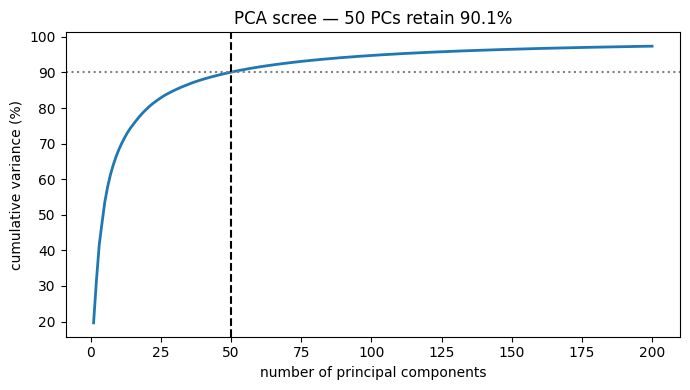

In [6]:
try:
    Xfull = feature_store["resnet50"]["full"]
    pca_full = PCA(n_components=min(200, Xfull.shape[0]-1, Xfull.shape[1]),
                   random_state=cfg.SEED).fit(Xfull)
    cum = np.cumsum(pca_full.explained_variance_ratio_); k = cfg.PCA_COMPONENTS
    def n_for(th):
        return int(np.argmax(cum >= th) + 1) if cum[-1] >= th else f">{len(cum)}"
    print(f"ResNet50 ({MODE}): top {k} PCs retain {cum[k-1]*100:.1f}% of variance")
    print(f"   components for 90% = {n_for(0.90)}, 95% = {n_for(0.95)}, 99% = {n_for(0.99)}")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, len(cum)+1), cum*100, lw=2)
    ax.axvline(k, ls="--", c="k"); ax.axhline(cum[k-1]*100, ls=":", c="grey")
    ax.set_xlabel("number of principal components"); ax.set_ylabel("cumulative variance (%)")
    ax.set_title(f"PCA scree — {k} PCs retain {cum[k-1]*100:.1f}%")
    fig.tight_layout(); fig.savefig(FEAT_DIR / "pca_scree.png", dpi=200, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("scree skipped:", e)

## 4 · Clustering baselines across backbones (5-class & 6-class)

GMM, KMeans, Agglomerative and Spectral on each backbone's PCA-50, scored against expert
labels. Each algorithm is wrapped in `try/except`.

In [7]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score)

def cluster_once(X, y_true, n):
    algos = {
        "GMM": GaussianMixture(n_components=n, covariance_type="full", random_state=cfg.SEED),
        "KMeans": KMeans(n_clusters=n, n_init=10, random_state=cfg.SEED),
        "Agglomerative": AgglomerativeClustering(n_clusters=n),
        "Spectral": SpectralClustering(n_clusters=n, random_state=cfg.SEED,
                        affinity="nearest_neighbors", n_neighbors=min(10, len(X)-1),
                        assign_labels="kmeans"),
    }
    ss = min(2000, len(X)); out = []
    for name, algo in algos.items():
        try:
            pred = algo.fit_predict(X)
            out.append(dict(algorithm=name,
                            ARI=adjusted_rand_score(y_true, pred),
                            NMI=normalized_mutual_info_score(y_true, pred),
                            silhouette=silhouette_score(X, pred, sample_size=ss,
                                                        random_state=cfg.SEED)))
        except Exception as e:
            print(f"      [{name}] failed: {type(e).__name__}: {e}")
            out.append(dict(algorithm=name, ARI=np.nan, NMI=np.nan, silhouette=np.nan))
    return out

records = []
for arch in tqdm(list(feature_store), desc="clustering"):
    fs = feature_store[arch]
    for tag, X, yt, n in [("5-class", fs["pca5"], y5, len(rc.CLASSES_5)),
                          ("6-class", fs["pca6"], y6, len(rc.CLASSES_6))]:
        for r in cluster_once(X, yt, n):
            r.update(backbone=arch, class_set=tag); records.append(r)

res = pd.DataFrame(records)[["backbone", "class_set", "algorithm", "ARI", "NMI", "silhouette"]]
res.to_csv(FEAT_DIR / f"clustering_comparison_{MODE}.csv", index=False)
print("saved", FEAT_DIR / f"clustering_comparison_{MODE}.csv")
res.round(3)

clustering:   0%|          | 0/4 [00:00<?, ?it/s]

saved Outputs\unsupervised\clustering_comparison_sq224.csv


,backbone,class_set,algorithm,ARI,NMI,silhouette
0,resnet50,5-class,GMM,0.828,0.832,0.133
1,resnet50,5-class,KMeans,0.646,0.688,0.148
2,resnet50,5-class,Agglomerative,0.747,0.753,0.130
3,resnet50,5-class,Spectral,0.570,0.706,0.171
4,resnet50,6-class,GMM,0.673,0.702,0.102
5,resnet50,6-class,KMeans,0.502,0.577,0.121
6,resnet50,6-class,Agglomerative,0.443,0.590,0.098
7,resnet50,6-class,Spectral,0.514,0.640,0.138
8,vit_b_16,5-class,GMM,0.596,0.701,0.118
9,vit_b_16,5-class,KMeans,0.685,0.713,0.167


In [8]:
# headline check: ResNet50 5-class GMM should be ~0.84 with USE_NATIVE_TRANSFORM=False
row = res[(res.backbone=="resnet50") & (res.class_set=="5-class") & (res.algorithm=="GMM")]
if len(row):
    print(f"ResNet50 5-class GMM  ARI={row.ARI.values[0]:.3f}  NMI={row.NMI.values[0]:.3f}"
          f"   (manuscript: 0.841 / 0.850)")
best = (res.dropna(subset=["ARI"]).sort_values("ARI", ascending=False)
           .groupby(["backbone", "class_set"]).head(1).sort_values(["backbone", "class_set"]))
print("\nBest algorithm per backbone / class set (by ARI):")
best.round(3)

ResNet50 5-class GMM  ARI=0.828  NMI=0.832   (manuscript: 0.841 / 0.850)

Best algorithm per backbone / class set (by ARI):


,backbone,class_set,algorithm,ARI,NMI,silhouette
24,convnext_base,5-class,GMM,0.800,0.792,0.137
28,convnext_base,6-class,GMM,0.637,0.661,0.097
0,resnet50,5-class,GMM,0.828,0.832,0.133
4,resnet50,6-class,GMM,0.673,0.702,0.102
19,swin_v2_b,5-class,Spectral,0.718,0.726,0.153
23,swin_v2_b,6-class,Spectral,0.515,0.580,0.126
10,vit_b_16,5-class,Agglomerative,0.756,0.755,0.141
12,vit_b_16,6-class,GMM,0.615,0.648,0.113


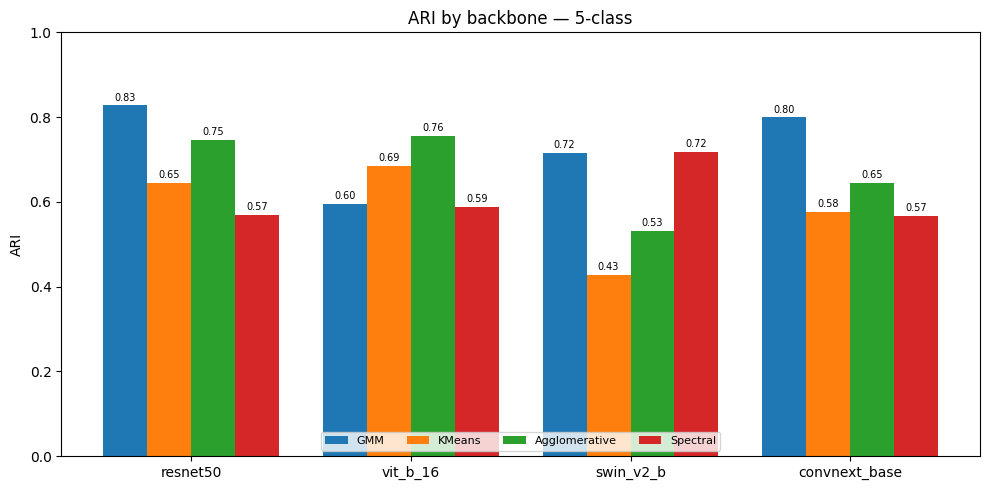

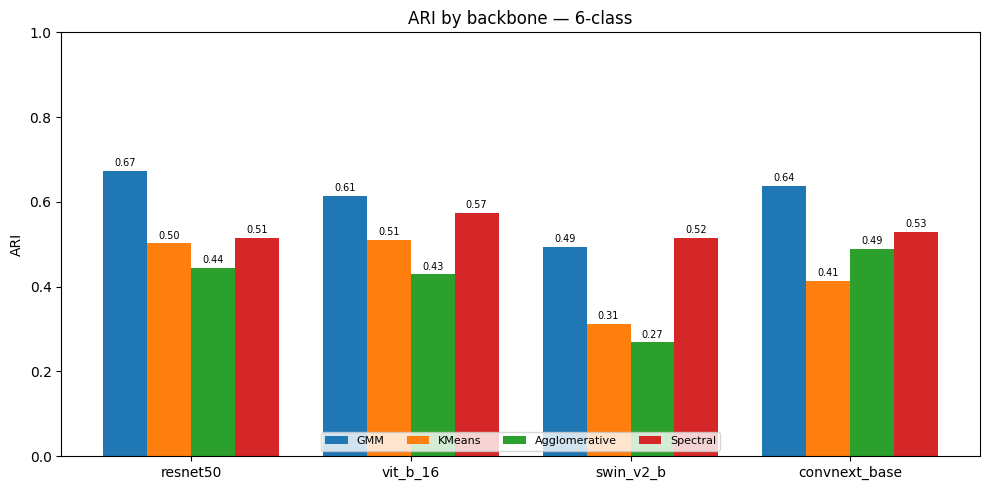

In [9]:
def plot_backbone_comparison(res, class_set, metric="ARI"):
    sub = res[res.class_set == class_set]
    backbones = sub.backbone.unique()
    algos = ["GMM", "KMeans", "Agglomerative", "Spectral"]
    x = np.arange(len(backbones)); w = 0.2
    fig, ax = plt.subplots(figsize=(10, 5))
    for j, algo in enumerate(algos):
        vals = [sub[(sub.backbone == b) & (sub.algorithm == algo)][metric].values[0]
                for b in backbones]
        bars = ax.bar(x + (j - 1.5) * w, vals, w, label=algo)
        ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(backbones)
    ax.set_ylabel(metric); ax.set_ylim(0, 1)
    ax.set_title(f"{metric} by backbone — {class_set}")
    ax.legend(ncol=4, fontsize=8, loc="lower center")
    fig.tight_layout()
    fig.savefig(FEAT_DIR / f"backbone_comparison_{class_set}_{metric}_{MODE}.png",
                dpi=200, bbox_inches="tight")
    plt.show()

plot_backbone_comparison(res, "5-class", "ARI")
plot_backbone_comparison(res, "6-class", "ARI")

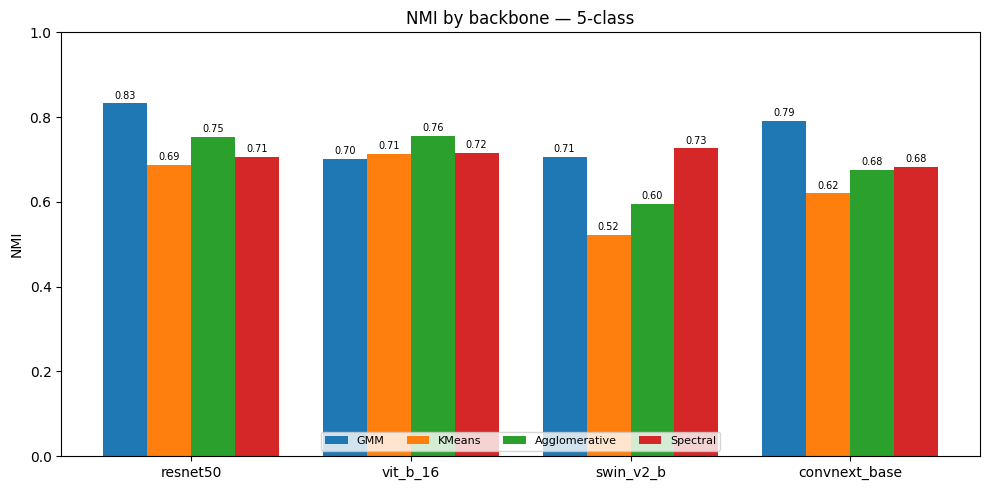

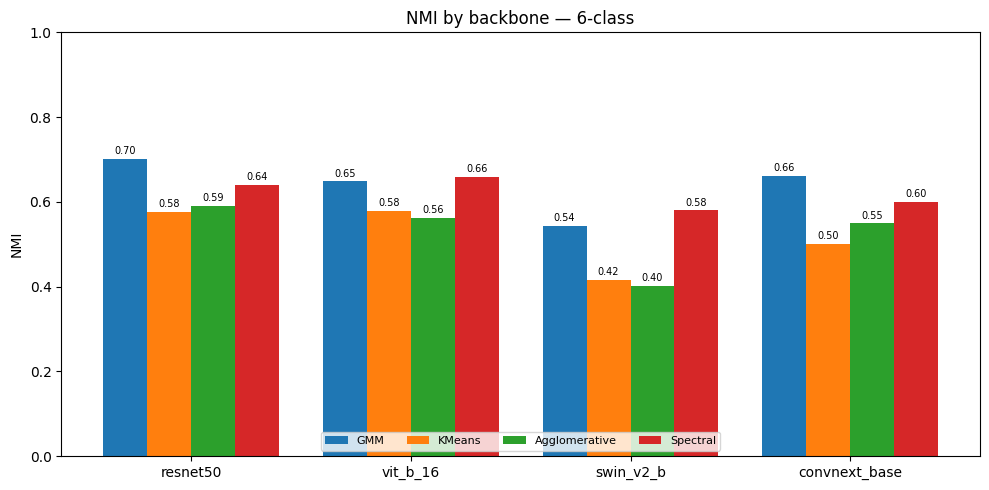

In [10]:
def plot_backbone_comparison(res, class_set, metric="NMI"):
    sub = res[res.class_set == class_set]
    backbones = sub.backbone.unique()
    algos = ["GMM", "KMeans", "Agglomerative", "Spectral"]
    x = np.arange(len(backbones)); w = 0.2
    fig, ax = plt.subplots(figsize=(10, 5))
    for j, algo in enumerate(algos):
        vals = [sub[(sub.backbone == b) & (sub.algorithm == algo)][metric].values[0]
                for b in backbones]
        bars = ax.bar(x + (j - 1.5) * w, vals, w, label=algo)
        ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(backbones)
    ax.set_ylabel(metric); ax.set_ylim(0, 1)
    ax.set_title(f"{metric} by backbone — {class_set}")
    ax.legend(ncol=4, fontsize=8, loc="lower center")
    fig.tight_layout()
    fig.savefig(FEAT_DIR / f"backbone_comparison_{class_set}_{metric}_{MODE}.png",
                dpi=200, bbox_inches="tight")
    plt.show()

plot_backbone_comparison(res, "5-class", "NMI")
plot_backbone_comparison(res, "6-class", "NMI")

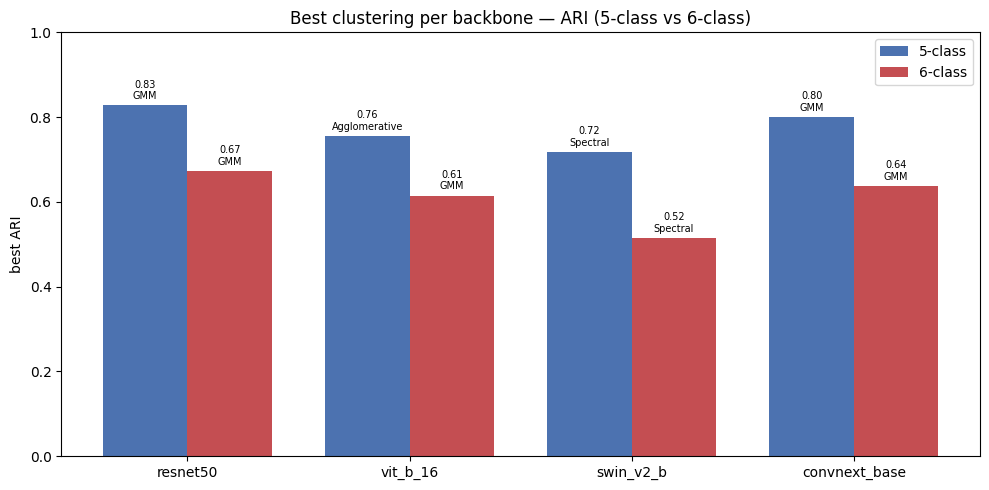

In [11]:
def plot_best_5v6(res, metric="ARI"):
    backbones = res.backbone.unique()
    # best algorithm per (backbone, class_set) by the metric
    def pick(bb, cs):
        s = res[(res.backbone == bb) & (res.class_set == cs)].dropna(subset=[metric])
        r = s.loc[s[metric].idxmax()]
        return r[metric], r["algorithm"]

    v5 = [pick(b, "5-class") for b in backbones]
    v6 = [pick(b, "6-class") for b in backbones]

    x = np.arange(len(backbones)); w = 0.38
    fig, ax = plt.subplots(figsize=(10, 5))
    b5 = ax.bar(x - w/2, [v for v, _ in v5], w, label="5-class", color="#4C72B0")
    b6 = ax.bar(x + w/2, [v for v, _ in v6], w, label="6-class", color="#C44E52")

    # annotate each bar with its value and the winning algorithm
    for bars, vals in [(b5, v5), (b6, v6)]:
        for rect, (val, algo) in zip(bars, vals):
            ax.text(rect.get_x() + rect.get_width()/2, val + 0.01,
                    f"{val:.2f}\n{algo}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x); ax.set_xticklabels(backbones)
    ax.set_ylabel(f"best {metric}"); ax.set_ylim(0, 1)
    ax.set_title(f"Best clustering per backbone — {metric} (5-class vs 6-class)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FEAT_DIR / f"best_backbone_5v6_{metric}_{MODE}.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_best_5v6(res, "ARI")

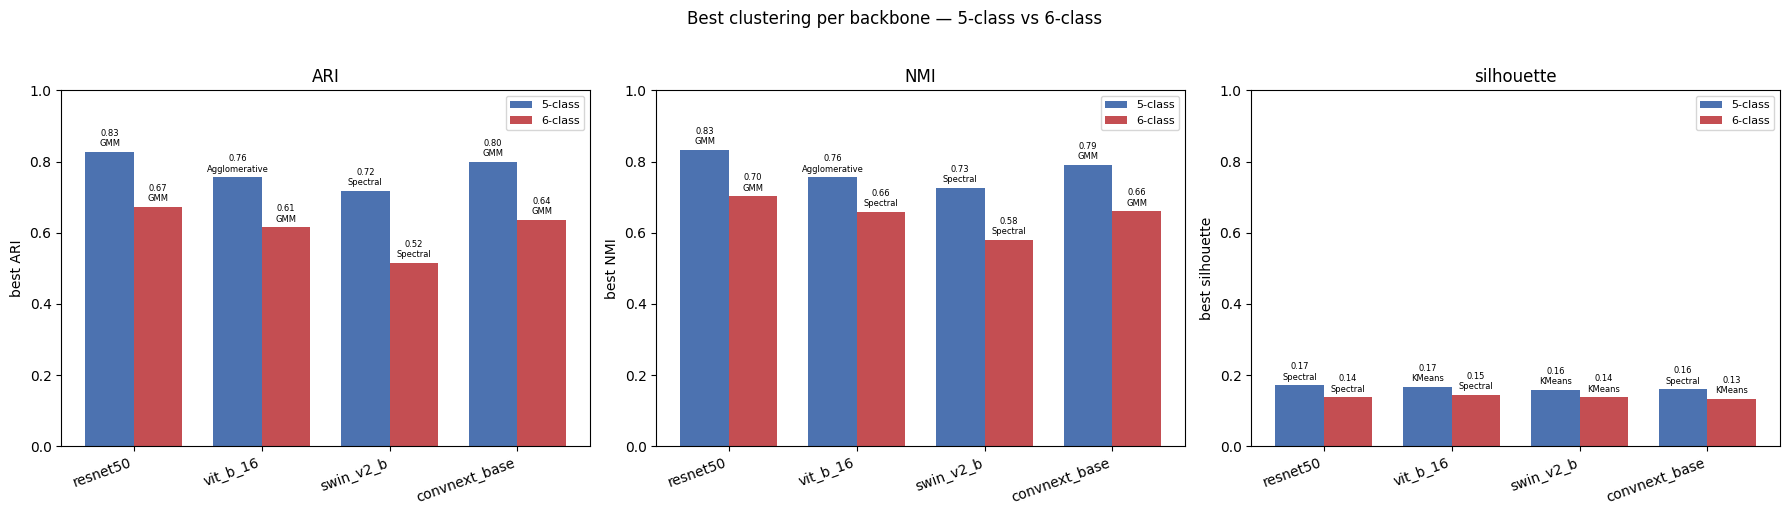

In [12]:
def plot_best_5v6(res, metrics=("ARI", "NMI", "silhouette")):
    backbones = res.backbone.unique()
    x = np.arange(len(backbones)); w = 0.38
    fig, axes = plt.subplots(1, len(metrics), figsize=(6*len(metrics), 5), squeeze=False)

    for ax, metric in zip(axes[0], metrics):
        def pick(bb, cs):
            s = res[(res.backbone == bb) & (res.class_set == cs)].dropna(subset=[metric])
            r = s.loc[s[metric].idxmax()]
            return r[metric], r["algorithm"]
        v5 = [pick(b, "5-class") for b in backbones]
        v6 = [pick(b, "6-class") for b in backbones]

        b5 = ax.bar(x - w/2, [v for v, _ in v5], w, label="5-class", color="#4C72B0")
        b6 = ax.bar(x + w/2, [v for v, _ in v6], w, label="6-class", color="#C44E52")
        for bars, vals in [(b5, v5), (b6, v6)]:
            for rect, (val, algo) in zip(bars, vals):
                ax.text(rect.get_x()+rect.get_width()/2, val + 0.01,
                        f"{val:.2f}\n{algo}", ha="center", va="bottom", fontsize=6)

        ax.set_xticks(x); ax.set_xticklabels(backbones, rotation=20, ha="right")
        ax.set_ylabel(f"best {metric}"); ax.set_ylim(0, 1)
        ax.set_title(metric); ax.legend(fontsize=8)

    fig.suptitle("Best clustering per backbone — 5-class vs 6-class", y=1.02)
    fig.tight_layout()
    fig.savefig(FEAT_DIR / f"best_backbone_5v6_all_{MODE}.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_best_5v6(res)

## 5 · t-SNE per backbone (6-class) and the 5-vs-6 partial-chalky view

In [6]:
def load_feature_store(backbones=BACKBONES):
    store = {}
    for arch in backbones:
        full_p = FEAT_DIR / f"{arch}_{MODE}_features_6class.npy"
        pca6_p = FEAT_DIR / f"{arch}_{MODE}_pca{cfg.PCA_COMPONENTS}_6class.npy"
        pca5_p = FEAT_DIR / f"{arch}_{MODE}_pca{cfg.PCA_COMPONENTS}_5class.npy"
        if not full_p.exists():
            print(f"[{arch}] no cache -> skipped")
            continue
        store[arch] = {
            "full": np.load(full_p),
            "pca6": np.load(pca6_p),
            "pca5": np.load(pca5_p),
        }
    return store

feature_store = load_feature_store()
print("loaded:", list(feature_store))

y6 = np.load(FEAT_DIR / "labels_6class.npy")
g6 = np.load(FEAT_DIR / "grainids_6class.npy",allow_pickle=True)

loaded: ['resnet50', 'vit_b_16', 'swin_v2_b', 'convnext_base']


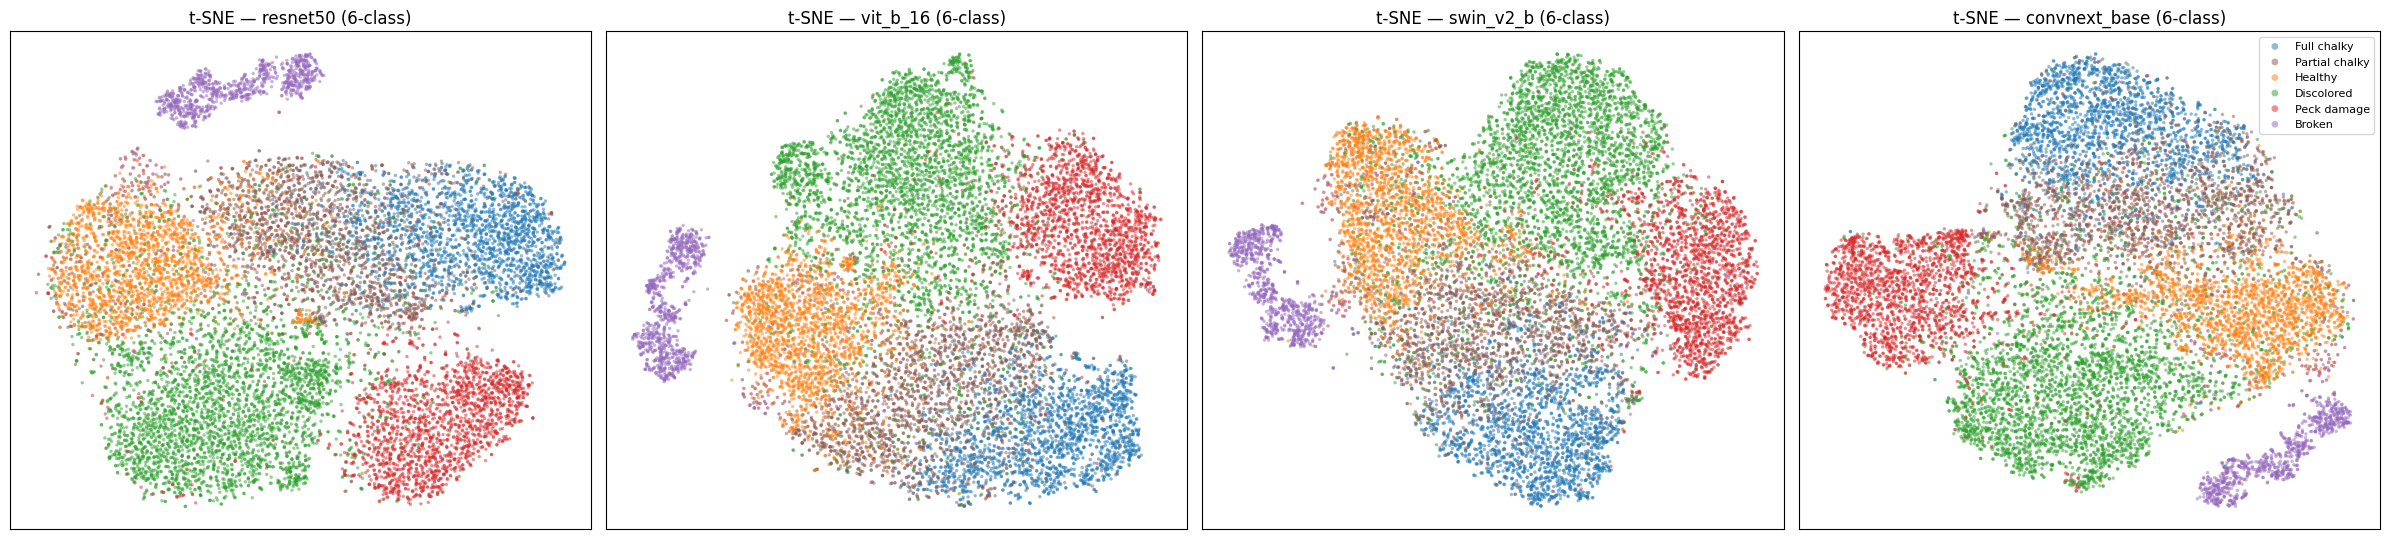

In [7]:
from sklearn.manifold import TSNE
archs = list(feature_store)
fig, axes = plt.subplots(1, max(1, len(archs)), figsize=(6*max(1, len(archs)), 5.5), squeeze=False)
for ax, arch in zip(axes[0], archs):
    try:
        Xp = feature_store[arch]["pca6"]
        emb = TSNE(n_components=2, random_state=cfg.SEED, init="pca",
                   perplexity=min(30, max(5, len(Xp)//100))).fit_transform(Xp)
        scatter_classes(ax, emb, y6, rc.CLASSES_6)   # per-backbone cell
        ax.set_title(f"t-SNE — {arch} (6-class)"); ax.set_xticks([]); ax.set_yticks([])
    except Exception as e:
        ax.set_title(f"{arch}: t-SNE failed"); print(f"[{arch}] t-SNE failed: {e}")
axes[0][-1].legend(markerscale=2, fontsize=8, loc="best")
fig.tight_layout(); fig.savefig(FEAT_DIR / f"tsne_backbones_6class_{MODE}.png", dpi=200, bbox_inches="tight")
plt.show()

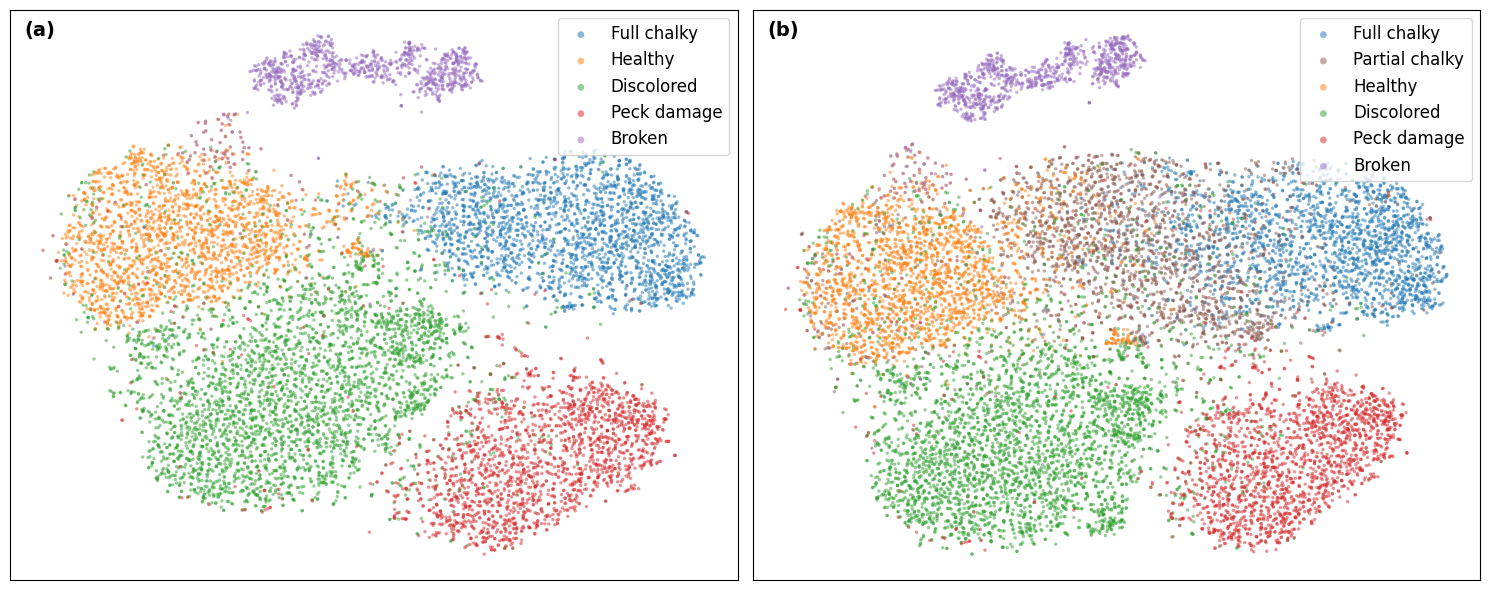

In [10]:
try:
    fs = feature_store["resnet50"]
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    for A, X, yt, classes, panel in [(ax[0], fs["pca5"], y5, rc.CLASSES_5, "(a)"),
                                     (ax[1], fs["pca6"], y6, rc.CLASSES_6, "(b)")]:
        emb = TSNE(n_components=2, random_state=cfg.SEED, init="pca",
                   perplexity=min(30, max(5, len(X)//100))).fit_transform(X)

        scatter_classes(A, emb, yt, classes)   # 5-vs-6 cell (A/yt/classes)
        A.text(0.02, 0.98, panel, transform=A.transAxes, ha="left", va="top",
               fontsize=14, fontweight="bold")
        A.set_xticks([]); A.set_yticks([]); A.legend(markerscale=2, fontsize=12)
    fig.tight_layout(); fig.savefig(FEAT_DIR / f"tsne_resnet50_5_vs_6_{MODE}.png", dpi=200, bbox_inches="tight")
    fig.savefig(FEAT_DIR / f"tsne_resnet50_5_vs_6_{MODE}.pdf", dpi=200, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("resnet50 5-vs-6 t-SNE skipped:", e)

---
### Outputs
* `Outputs/unsupervised/{backbone}_{MODE}_features_6class.npy` — full embeddings (frozen)
* `Outputs/unsupervised/{backbone}_{MODE}_pca50_5class.npy` / `_6class.npy` — PCA-50 (frozen)
* `Outputs/unsupervised/labels_6class.npy`, `grainids_6class.npy`
* `Outputs/unsupervised/clustering_comparison_{MODE}.csv`
* `Outputs/unsupervised/pca_scree.png`, `tsne_*_{MODE}.png`


## Getting border line percentage

In [3]:
import numpy as np
from sklearn.mixture import GaussianMixture

X = np.load(FEAT_DIR / "resnet50_sq224_pca50_5class.npy")   # your saved PCA-50, 5-class
gmm = GaussianMixture(n_components=5, covariance_type="full",
                      random_state=cfg.SEED).fit(X)
proba = gmm.predict_proba(X)
top = proba.max(axis=1)                    # confidence of the assigned cluster
for thr in (0.90, 0.80, 0.70):
    frac = (top < thr).mean() * 100
    print(f"borderline (top posterior < {thr}): {frac:.1f}%")

borderline (top posterior < 0.9): 1.7%
borderline (top posterior < 0.8): 0.9%
borderline (top posterior < 0.7): 0.6%
